Below is a **clean learning + implementation guide for Snell’s Law → refraction in ray tracing**, with:

* step-by-step math
* meaning of each term
* Markdown table with LaTeX
* Python implementation (with comments explaining *what changed at each step*)

---

# 1. Snell’s Law (Core Physics)

## Equation

$$
\eta \sin\theta = \eta' \sin\theta'
$$

---

## Meaning Table

| Concept          | Formula                               | Meaning                                       | Purpose in Ray Tracing          |
| ---------------- | ------------------------------------- | --------------------------------------------- | ------------------------------- |
| Snell’s Law      | $\eta \sin\theta = \eta' \sin\theta'$ | Relates angles when light enters a new medium | Determines how much a ray bends |
| Refractive index | $\eta$                                | Optical density of material                   | Controls bending strength       |
| Incident angle   | $\theta$                              | Angle between incoming ray and normal         | Input geometry                  |
| Refracted angle  | $\theta'$                             | Angle of outgoing ray                         | Output direction                |

---

# 2. Goal in Ray Tracing

We want:

> Convert incoming ray direction → refracted ray direction vector

Not angles.

So we transform Snell’s Law into **vector form**.

---

# 3. Key Vector Idea

We avoid angles using dot product:

$$
\cos\theta = \hat{a} \cdot \hat{b}
$$

So:

* $\cos\theta = -\mathbf{R} \cdot \mathbf{n}$
  (because ray points inward, normal points outward)

---

# 4. Vector Decomposition Idea

We split refracted ray:

$$
\mathbf{R'} = \mathbf{R'*\perp} + \mathbf{R'*\parallel}
$$

| Component               | Meaning                            |
| ----------------------- | ---------------------------------- |
| $\mathbf{R'_\perp}$     | bending part (controls refraction) |
| $\mathbf{R'_\parallel}$ | ensures vector stays unit length   |

---

# 5. Final Refraction Formula Used in Ray Tracing

### Perpendicular component:

$$
\mathbf{R'_\perp} = \eta \left(\mathbf{R} + (,-\mathbf{R}\cdot \mathbf{n},) \mathbf{n} \right)
$$

### Parallel component:

$$
\mathbf{R'*\parallel} = -\sqrt{1 - |\mathbf{R'*\perp}|^2},\mathbf{n}
$$

---

# 6. Step-by-step meaning table

| Step | Formula                                   | What it does             |
| ---- | ----------------------------------------- | ------------------------ |
| 1    | $\mathbf{R} = \text{unit direction}$      | Normalize incoming ray   |
| 2    | $cos\theta = -\mathbf{R}\cdot \mathbf{n}$ | Find incident angle      |
| 3    | scale factor $\eta$                       | Apply refractive ratio   |
| 4    | perpendicular part                        | bends ray sideways       |
| 5    | parallel part                             | fixes direction + length |
| 6    | sum                                       | final refracted ray      |

---

# 7. Python Implementation (Ray Tracing Style)

We implement:

* `dot`
* `length_squared`
* `refract`

---

## Vector utilities

```python
import math

class Vec3:
    def __init__(self, x, y, z):
        self.x = x
        self.y = y
        self.z = z

    def __add__(self, other):
        return Vec3(self.x + other.x,
                    self.y + other.y,
                    self.z + other.z)

    def __sub__(self, other):
        return Vec3(self.x - other.x,
                    self.y - other.y,
                    self.z - other.z)

    def __mul__(self, t):
        return Vec3(self.x * t,
                    self.y * t,
                    self.z * t)

    def dot(self, other):
        return self.x * other.x + self.y * other.y + self.z * other.z

    def length_squared(self):
        return self.dot(self)
```

---

## Normalize vector

```python
def unit_vector(v):
    len_inv = 1.0 / math.sqrt(v.length_squared())
    return v * len_inv
```

---

# 8. Refraction Function (Core Logic)

```python
def refract(uv, n, etai_over_etat):
    """
    uv: unit direction of incoming ray
    n : surface normal
    etai_over_etat: ratio of refractive indices (η / η')
    """

    # STEP 1: compute cos(theta)
    # CHANGED: we use dot product instead of angle
    cos_theta = min((-uv).dot(n), 1.0)

    # STEP 2: perpendicular component (bending part)
    # CHANGED: scales direction using Snell’s Law form
    r_out_perp = (uv + n * cos_theta) * etai_over_etat

    # STEP 3: parallel component (keeps unit length)
    # CHANGED: ensures physical constraint |R'| = 1
    r_out_parallel = n * (-math.sqrt(abs(1.0 - r_out_perp.length_squared())))

    # STEP 4: final refracted ray
    return r_out_perp + r_out_parallel
```

---

# 9. Why each step exists (important intuition)

| Step               | Why it exists                                      |
| ------------------ | -------------------------------------------------- |
| cosθ computation   | replaces geometry with dot product                 |
| perpendicular part | applies bending (Snell’s law effect)               |
| parallel part      | ensures ray stays valid unit vector                |
| sqrt term          | enforces physical constraint (energy conservation) |

---

# 10. Dielectric Material (Ray Tracing Behavior)

```python
class Dielectric:
    def __init__(self, ref_idx):
        # refractive index (glass ~1.5)
        self.ref_idx = ref_idx

    def scatter(self, ray_in, hit_record):
        # Always white attenuation (glass does not absorb light)
        attenuation = Vec3(1.0, 1.0, 1.0)

        # STEP 1: determine if entering or exiting
        if hit_record.front_face:
            etai_over_etat = 1.0 / self.ref_idx
        else:
            etai_over_etat = self.ref_idx

        # STEP 2: normalize ray direction
        unit_dir = unit_vector(ray_in.direction)

        # STEP 3: compute refracted ray
        refracted = refract(unit_dir, hit_record.normal, etai_over_etat)

        # STEP 4: generate scattered ray
        scattered = Ray(hit_record.p, refracted)

        return True, attenuation, scattered
```

---

# 11. Key Insight (why glass works or breaks)

If anything is wrong:

### ❌ symptoms

* upside-down world missing
* black patches
* weird distortion
* no proper bending

### ❌ usually caused by:

* wrong normal direction
* missing unit vector
* wrong sign in dot product
* incorrect η ratio (inside/outside swapped)

---

# 12. Mental Model (simple)

Think:

> Refraction = “push ray sideways + adjust forward speed so total length stays 1”

---

If you want next step, I can show:

* how **total internal reflection is added (critical angle)**
* or **Schlick approximation (real glass looks faster + realistic reflection mix)**
* or a **debug checklist for ray tracers when glass looks wrong**

Just tell 👍


In [11]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [12]:
from util.material import Material
from util.ray import Ray
from util.vec3 import Vec3, reflect, unit_vector, random_unit_vector, dot
class Metal(Material):
    def __init__(self, albedo, fuzz=0.0):
        # metal color
        self.albedo = albedo

        # surface roughness (0 = perfect mirror, 1 = very rough)
        self.fuzz = min(fuzz, 1.0)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: normalize incoming ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 2: perfect reflection direction
        # R = V - 2(V·N)N
        # ==========================================
        reflected = reflect(unit_dir, rec.normal)

        # ==========================================
        # STEP 3: add fuzz (surface imperfection)
        # ==========================================
        scattered_dir = reflected + self.fuzz * random_unit_vector()

        # ==========================================
        # STEP 4: build scattered ray
        # ==========================================
        scattered = Ray(rec.p, scattered_dir)

        # ==========================================
        # STEP 5: energy attenuation (metal tint)
        # ==========================================
        attenuation = self.albedo

        # ==========================================
        # MUST return exactly 2 values
        # ==========================================
        return scattered, attenuation

In [13]:
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot


def refract(uv, n, etai_over_etat):
    """
    Vector refraction based on Snell's Law.

    uv : unit incident direction
    n  : surface normal
    etai_over_etat : ratio of refractive indices (η / η')
    """

    # ==========================================
    # STEP 1: cos(theta)
    # cosθ = min(-uv · n, 1)
    # ==========================================
    cos_theta = min(dot(-uv, n), 1.0)

    # ==========================================
    # STEP 2: perpendicular component
    # R⊥ = (η/η') (uv + cosθ n)
    # ==========================================
    r_out_perp = (uv + n * cos_theta) * etai_over_etat

    # ==========================================
    # STEP 3: parallel component
    # R∥ = -sqrt(1 - |R⊥|²) n
    # ==========================================
    r_out_parallel = n * (-math.sqrt(abs(1.0 - r_out_perp.length_squared())))

    # ==========================================
    # STEP 4: final refracted direction
    # ==========================================
    return r_out_perp + r_out_parallel

In [14]:
class Dielectric(Material):

    def __init__(self, refraction_index):
        # refractive index of material (glass ~1.5)
        self.refraction_index = refraction_index

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: glass does NOT absorb light
        # ==========================================
        attenuation = Vec3(1.0, 1.0, 1.0)

        # ==========================================
        # STEP 2: determine entering vs exiting
        #
        # C++:
        # ri = front_face ? (1/n) : n
        # ==========================================
        if rec.front_face:
            etai_over_etat = 1.0 / self.refraction_index
        else:
            etai_over_etat = self.refraction_index

        # ==========================================
        # STEP 3: normalize incoming direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 4: apply Snell's Law refraction
        # ==========================================
        refracted_dir = refract(unit_dir, rec.normal, etai_over_etat)

        # ==========================================
        # STEP 5: create refracted ray
        # ==========================================
        scattered = Ray(rec.p, refracted_dir)

        # ==========================================
        # MUST return ONLY 2 values
        # ==========================================
        return scattered, attenuation

In [18]:
from util.vec3 import Vec3, Color, Point3

from util.metal.lambertian import Lambertian
#from util.metal.metal import Metal
#from util.metal.dielectric import Dielectric   # ✅ IMPORTANT FIX
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
from util.metal.camera import Camera


# ==========================================
# WORLD
# ==========================================
world = HittableList()


# ==========================================
# MATERIALS (C++ → Python mapping)
# ==========================================

# Diffuse (Lambertian)
material_ground = Lambertian(Color(0.8, 0.8, 0.0))
material_center = Lambertian(Color(0.1, 0.2, 0.5))

# Metal
material_right = Metal(Color(0.8, 0.6, 0.2), 1.0)

# Glass (THIS is the missing part)
material_left = Dielectric(1.50)   # ✅ correct C++ equivalent


# ==========================================
# SCENE OBJECTS
# ==========================================

# Ground
world.add(
    Sphere(
        Point3(0.0, -100.5, -1.0),
        100.0,
        material_ground
    )
)

# Center sphere
world.add(
    Sphere(
        Point3(0.0, 0.0, -1.2),
        0.5,
        material_center
    )
)

# Left sphere (GLASS)
world.add(
    Sphere(
        Point3(-1.0, 0.0, -1.0),
        0.5,
        material_left
    )
)

# Right sphere (METAL)
world.add(
    Sphere(
        Point3(1.0, 0.0, -1.0),
        0.5,
        material_right
    )
)


# ==========================================
# CAMERA
# ==========================================
cam = Camera()
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400

cam.samples_per_pixel = 100
cam.max_depth = 50


# ==========================================
# RENDER
# ==========================================
cam.render(world)

100%|██████████| 225/225 [08:49<00:00,  2.36s/it, CPU=41.4%, RAM=79.0%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=743.0MB]


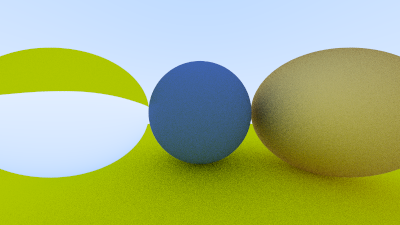

In [19]:
cam.show()